# Task 131: Crowd Congestion Detection System - Modular Development Notebook

This notebook imports the modular python scripts from `Code/` to run and verify the Crowd Congestion Detection System.

### Architecture Workflow:
1. **Pretrained Detector**: Uses YOLOv8n to identify persons (class 0).
2. **Custom Tracker**: Matches person bounding boxes across frames using Intersection over Union (IoU) tracking.
3. **Spatial Zone Assignment**: Assesses if a person's centroid (bottom-middle of their bounding box) is within defined polygons using `cv2.pointPolygonTest`.
4. **Crowd Density Estimation**: Determines LOW, MODERATE, HIGH, or CRITICAL density per zone.
5. **State Machine Congestion Monitoring**: Transitions zone state from NORMAL to CONGESTED when high density persists for >= `min_duration_seconds`.
6. **Alert Logging & Telemetry**: Saves events to `alerts.log` and telemetry to `crowd_density.csv`.
7. **Heatmap Generation**: Smooths centroid positions into a density heatmap over a reference frame.

## 1. Environment Setup & Imports

Make sure you have installed all package dependencies. We append the `Code/` subdirectory to the Python path to import our modules.

In [1]:
# Install packages if running in a fresh environment like Colab
# !pip install -q ultralytics opencv-python pandas pyyaml matplotlib numpy

import os
import sys
import yaml
import pandas as pd
import matplotlib.pyplot as plt

# Ensure the notebook can import modular scripts relative to task directory
sys.path.append(os.path.abspath('.'))
sys.path.append(os.path.abspath('../Code'))
sys.path.append(os.path.abspath('./Code'))

from utils import video_frame_generator, DENSITY_COLORS
from detector import PersonDetector
from tracker import SimpleIoUTracker
from zone_manager import ZoneManager
from alert_manager import AlertManager
from heatmap_generator import HeatmapGenerator
from output_writer import OutputWriter

print("✅ All modules imported successfully!")

✅ All modules imported successfully!


## 2. Load and Display Config

We read the configurations and boundaries defined in `config.yaml`.

In [2]:
config_path = '../config.yaml' if os.path.exists('../config.yaml') else 'config.yaml'

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)
    
print("🔧 Loaded Configuration:")
print(yaml.dump(config))

🔧 Loaded Configuration:
congestion:
  min_duration_seconds: 2.0
detector:
  confidence_threshold: 0.25
heatmap:
  alpha: 0.6
  colormap: COLORMAP_JET
  snapshot_interval_seconds: 30.0
model_path: Models/yolov8n.pt
output_dir: Outputs
tracker:
  iou_threshold: 0.3
  max_lost_frames: 30
video_path: Test_Videos/sample.mp4
zones:
- name: Main_Entrance_Zone
  polygon:
  - - 20
    - 20
  - - 370
    - 20
  - - 370
    - 410
  - - 20
    - 410
  thresholds:
    critical: 10
    high: 8
    low: 2
    moderate: 5
- name: Corridor_Zone
  polygon:
  - - 394
    - 20
  - - 748
    - 20
  - - 748
    - 410
  - - 394
    - 410
  thresholds:
    critical: 10
    high: 8
    low: 2
    moderate: 5



## 3. Run Pipeline

This cell runs the full modular pipeline on the configured video.

In [3]:
import time
import datetime
import json

# Resolve paths relative to task root
video_path = config.get("video_path", "Test_Videos/sample.mp4")
if not os.path.exists(video_path) and os.path.exists(os.path.join("..", video_path)):
    video_path = os.path.join("..", video_path)
    
output_dir = config.get("output_dir", "Outputs")
if not os.path.isabs(output_dir):
    output_dir = os.path.abspath(os.path.join(os.path.dirname(config_path), output_dir))
os.makedirs(output_dir, exist_ok=True)

model_path = config.get("model_path", "Models/yolov8n.pt")
if not os.path.exists(model_path) and os.path.exists(os.path.join("..", model_path)):
    model_path = os.path.join("..", model_path)

print(f"🎬 Processing Video: {video_path}")

# Initialize components
detector = PersonDetector(model_path=model_path, confidence_threshold=config['detector']['confidence_threshold'])
tracker = SimpleIoUTracker(iou_threshold=config['tracker']['iou_threshold'], max_lost_frames=config['tracker']['max_lost_frames'])
zone_manager = ZoneManager(zone_config=config['zones'], min_duration_seconds=config['congestion']['min_duration_seconds'])
alert_manager = AlertManager(log_path=os.path.join(output_dir, "alerts.log"))

# Connect callback transitions
zone_manager.register_callbacks(on_start=alert_manager.handle_congestion_start, on_end=alert_manager.handle_congestion_end)

heatmap_gen = HeatmapGenerator(output_dir=output_dir, colormap=config['heatmap']['colormap'], alpha=config['heatmap']['alpha'])

start_time = time.time()
processed_frames = 0
writer = None

frame_generator = video_frame_generator(video_path)
snapshot_interval = config['heatmap']['snapshot_interval_seconds']

for frame, frame_idx, fps, frame_count, width, height in frame_generator:
    if writer is None:
        writer = OutputWriter(
            video_output_path=os.path.join(output_dir, f"sample_annotated.mp4"),
            csv_output_path=os.path.join(output_dir, "crowd_density.csv"),
            fps=fps, width=width, height=height
        )
        
    detections = detector.detect(frame)
    active_tracks = tracker.update(detections, frame_idx)
    zone_states = zone_manager.update(active_tracks, frame_idx, fps)
    
    annotated_frame = writer.annotate_frame(frame, active_tracks, zone_states, config['zones'])
    writer.write_frame(annotated_frame)
    
    elapsed_sec = frame_idx / fps
    td = datetime.timedelta(seconds=elapsed_sec)
    video_time_str = str(td).split('.')[0]
    writer.write_telemetry(video_time_str, frame_idx, zone_states)
    
    heatmap_gen.update(active_tracks, frame)
    
    if snapshot_interval > 0 and frame_idx > 0 and int(frame_idx) % int(fps * snapshot_interval) == 0:
        snap_num = int(frame_idx // (fps * snapshot_interval))
        heatmap_gen.save_snapshot(f"heatmap_snapshot_{snap_num:03d}.png", frame)
        
    processed_frames += 1

if writer is not None:
    writer.close()
heatmap_gen.save_snapshot("heatmap_final.png")

elapsed_time = time.time() - start_time
avg_fps = processed_frames / elapsed_time
print(f"\n🎉 Pipeline Completed in {elapsed_time:.2f}s ({avg_fps:.2f} FPS)")

🎬 Processing Video: ..\Test_Videos/sample.mp4



🎉 Pipeline Completed in 102.73s (13.57 FPS)


## 4. Telemetry Visualization

Let's load the crowd count telemetry data and plot the live crowd count inside each zone over the course of the video.

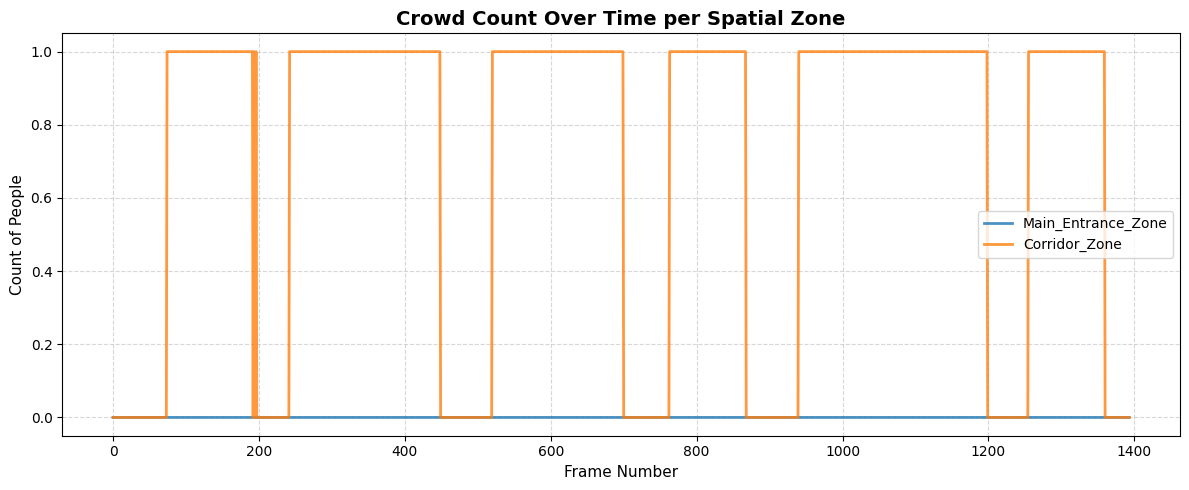

In [4]:
csv_path = os.path.join(output_dir, "crowd_density.csv")
df = pd.read_csv(csv_path)

plt.figure(figsize=(12, 5))
for zone_name in df['zone'].unique():
    zone_df = df[df['zone'] == zone_name]
    plt.plot(zone_df['frame_number'], zone_df['crowd_count'], label=zone_name, alpha=0.8, linewidth=2)
    
plt.title("Crowd Count Over Time per Spatial Zone", fontsize=14, fontweight='bold')
plt.xlabel("Frame Number", fontsize=11)
plt.ylabel("Count of People", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Density Heatmap Display

Display the final accumulated density heatmap overlaid on the reference frame.

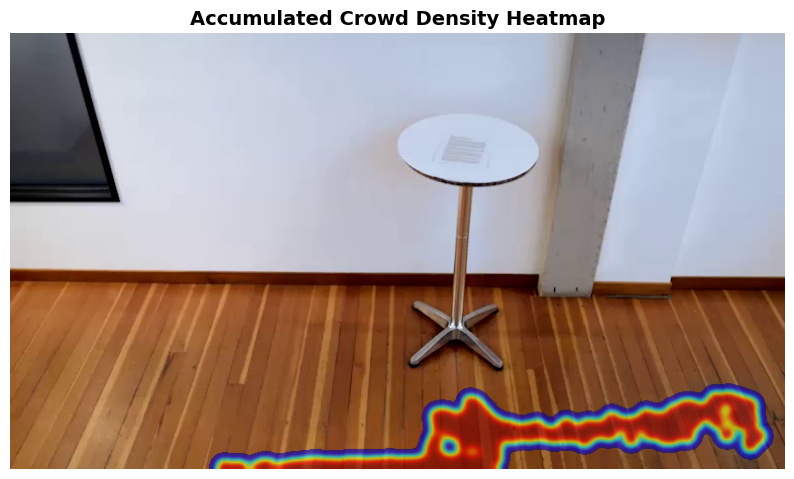

In [5]:
import cv2
heatmap_path = os.path.join(output_dir, "heatmap_final.png")
if os.path.exists(heatmap_path):
    img = cv2.imread(heatmap_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)
    plt.title("Accumulated Crowd Density Heatmap", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()
else:
    print("❌ Heatmap file not found!")

## 6. Show Congestion Alerts

We print the contents of the congestion alerts log.

In [6]:
alerts_path = os.path.join(output_dir, "alerts.log")
if os.path.exists(alerts_path):
    alerts_df = pd.read_csv(alerts_path)
    if len(alerts_df) > 0:
        display(alerts_df)
    else:
        print("No congestion events recorded with current thresholds.")
else:
    print("Alerts log file not found.")

No congestion events recorded with current thresholds.
